In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
# ==============================
# STEP 1 — LOAD DATASETS
# ==============================

import numpy as np
import pandas as pd

train_data = np.load("train.npy")
test_data = np.load("test.npy")

labels_df = pd.read_csv("trainLabels.csv")

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

print("\nLabels Data:")
print(labels_df.head())

Train Data Shape: (32, 32, 3)
Test Data Shape: (32, 32, 3)

Labels Data:
   id       label
0   1        frog
1   2       truck
2   3       truck
3   4        deer
4   5  automobile


In [24]:
# ==============================
# STEP 2 — CHECK LABEL COLUMNS
# ==============================

print("Column Names:")
print(labels_df.columns)

Column Names:
Index(['id', 'label'], dtype='str')


In [ ]:
# ==============================
# STEP 3 — SELECT CORRECT LABEL COLUMN
# ==============================
# assuming label column name is 'label'
y = labels_df.iloc[:, 1]

print("First 10 Labels:")
print(y[:10])

First 10 Labels:
0          frog
1         truck
2         truck
3          deer
4    automobile
5    automobile
6          bird
7         horse
8          ship
9           cat
Name: label, dtype: str


In [ ]:
# ==============================
# STEP 4 — ENCODE LABELS
# ==============================
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Encoded Labels:")
print(y_encoded[:10])

Encoded Labels:
[6 9 9 4 1 1 2 7 8 3]


In [25]:
# ==============================
# STEP 5 — CONVERT TO CATEGORICAL
# ==============================

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_encoded)

print("Categorical Shape:")
print(y_train.shape)

Categorical Shape:
(50000, 10)


In [39]:
# ==============================
# STEP 6 — CHECK IMAGE SHAPE
# ==============================

print("Single Image Shape:")
print(train_data[0].shape)

Single Image Shape:
(32, 3)


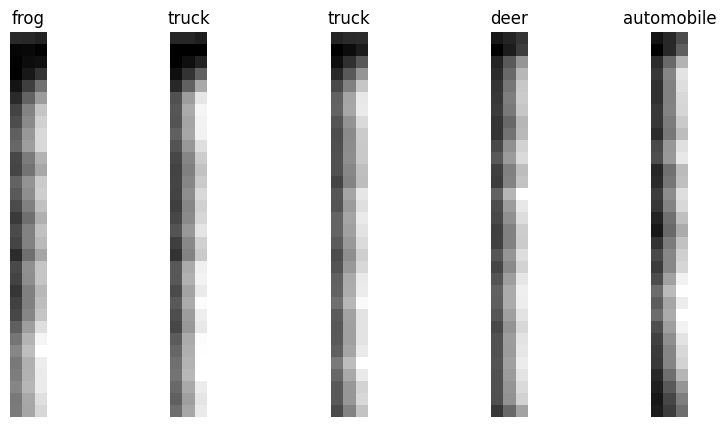

In [27]:
 # ==============================
# STEP 7 — DISPLAY SAMPLE IMAGES
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_data[i], cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')

plt.show()

In [40]:
# ==============================
# STEP 8 — NORMALIZE DATA
# ==============================

X_train = train_data / 255.0
X_test = test_data / 255.0

print("Normalization Completed")

print("Max Pixel Value:", X_train.max())
print("Min Pixel Value:", X_train.min())

Normalization Completed
Max Pixel Value: 1.0
Min Pixel Value: 0.0


In [28]:
 # ==============================
# STEP 9 — BUILD ANN MODEL
# ==============================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential()

# input layer
model.add(Flatten(input_shape=train_data[0].shape))

# hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# output layer
model.add(Dense(y_train.shape[1], activation='softmax'))

print("Model Built Successfully")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model Built Successfully


In [29]:
# ==============================
# STEP 10 — COMPILE MODEL
# ==============================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [30]:
# ==============================
# STEP 11 — MODEL SUMMARY
# ==============================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,322 (83.29 KB)

 Trainable params: 21,322 (83.29 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ==============================
# STEP 12 — TRAIN MODEL
# ==============================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.3911 - val_accuracy: 0.1429 - val_loss: 2.2302
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1600 - loss: 2.2958 - val_accuracy: 0.1429 - val_loss: 2.2237
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2400 - loss: 2.2303 - val_accuracy: 0.2857 - val_loss: 2.2223
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2400 - loss: 2.1817 - val_accuracy: 0.2857 - val_loss: 2.2266
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2800 - loss: 2.1431 - val_accuracy: 0.1429 - val_loss: 2.2377
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3200 - loss: 2.1106 - val_accuracy: 0.1429 - val_loss: 2.2540
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3200 - loss: 2.0816 - val_accuracy: 0.1429 - val_loss: 2.2723
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3200 - loss: 2.0547 - val_accuracy: 0.1429 - val_loss: 2

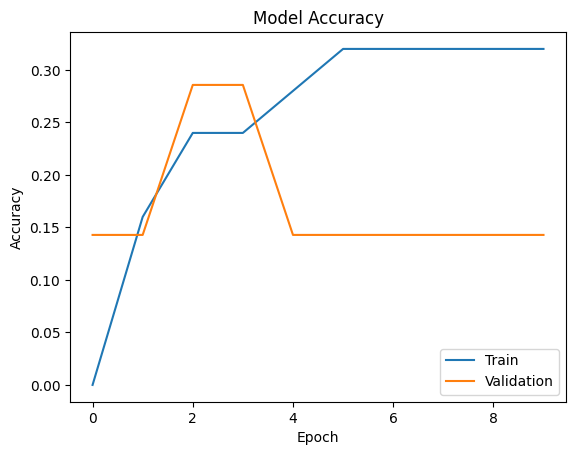

In [32]:
# ==============================
# STEP 13 — PLOT ACCURACY GRAPH
# ==============================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [33]:
# ==============================
# STEP 14 — PREDICT TEST DATA
# ==============================

predictions = model.predict(X_test)

print("Prediction Shape:")
print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction Shape:
(32, 10)


In [34]:
# ==============================
# STEP 15 — GET FINAL CLASSES
# ==============================

predicted_classes = np.argmax(predictions, axis=1)

print("First 10 Predictions:")
print(predicted_classes[:10])

First 10 Predictions:
[9 9 9 9 9 9 9 9 9 9]


In [35]:
# ==============================
# STEP 16 — CREATE SUBMISSION FILE
# ==============================

submission = pd.DataFrame({
    'Label': predicted_classes
})

print(submission.head())

   Label
0      9
1      9
2      9
3      9
4      9


In [36]:
# ==============================
# STEP 17 — SAVE CSV FILE
# ==============================

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully")

submission.csv saved successfully


In [37]:
# ==============================
# STEP 18 — SAVE MODEL
# ==============================

model.save("image_classification_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
